# Aula 09 - Aprendizado Supervisionado - Parte 3 (Árvores de Decisão, Random Forest & SVM)

**Disciplina:** Aprendizado de Máquina e Redes Neurais  
**Professor:** Eduardo Lázaro Roesler de Oliveira  
**Instituição:** UNIVEM — Centro Universitário de Marília  

---

> [!NOTE]
> 🔙 **De onde viemos:** Na Aula 08, aprendemos a classificar dados com Regressão Logística e KNN. Porém, quando os dados possuem regras condicionais complexas e atributos de tipos variados, precisamos de modelos que consigam criar divisões não-lineares intuitivas e transparentes.  
> 🎯 **Objetivo Principal da Aula:** Dominar os algoritmos de **Árvores de Decisão**, o poder do ensemble com **Random Forest (Floresta Aleatória)** e as **Support Vector Machines (SVM)**, compreendendo o cálculo de impureza de Gini, a extração de importância de atributos (`feature_importances_`) e o controle de profundidade para conter o *Overfitting*.  
> 🚀 **Para onde vamos:** Na próxima aula ('Avaliação de Modelos - Parte 1'), colocaremos à prova a confiabilidade dos nossos modelos: como garantir que a acurácia de 90% obtida pela Random Forest não foi apenas 'pura sorte' na divisão aleatória do `train_test_split`?

---

## Organização Tática da Aula

| Módulo | Atividade | Foco Pedagógico |
| :--- | :--- | :--- |
| **Módulo 1** | **Fundamentação Teórica & Árvores vs. SVM** | Divisão de nós por impureza de Gini/Entropia, intuição da margem máxima do SVM e Ensemble (Random Forest). |
| **Módulo 2** | **Mecanismo de Controle: Overfitting vs `max_depth`** | Como o crescimento descontrolado de uma árvore decora o treino e falha no teste. |
| **Módulo 3** | **Prática Guiada no Google Colab** | 8 blocos de código em Python minuciosamente comentados linha por linha e caixas de dúvidas comuns. |
| **Módulo 4** | **Prática Orientada & Experimentação Fácil** | Detecção de fraudes financeiras com Random Forest alterando o número de árvores. |
| **Módulo 5** | **Checklist de Autonomia & Bibliografia** | Autoavaliação do estudante e referências oficiais. |

## Módulo 1: Fundamentação Teórica & Algoritmos Não-Lineares

### 1.1 Árvores de Decisão e Impureza de Gini
Uma **Árvore de Decisão** funciona como um jogo de 20 perguntas (ou um fluxograma de decisão). Ela cria regras simples do tipo `se / senão` (`if/else`) baseadas nos atributos dos dados para dividir os grupos em subgrupos cada vez mais homogêneos ("puros").

O algoritmo escolhe a melhor pergunta avaliando a redução do **Índice de Impureza de Gini** ($Gini = 1 - \sum p_i^2$). 
- Um nó é considerado **totalmente puro ($Gini = 0$)** quando contém apenas amostras de uma única classe (ex: uma caixa com apenas maçãs).
- Um nó é **impuro ($Gini > 0$)** quando há mistura de classes (ex: uma caixa com metade maçãs e metade laranjas).

> [!TIP]
> 🍎 **Analogia Cotidiana — O Filtro de Frutas do Feirante:**  
> Imagine um feirante separando frutas. A primeira regra pode ser: *"A fruta é vermelha?"*. Se SIM, vai para a caixa A; se NÃO, vai para a caixa B. Em seguida, na caixa A ele pergunta: *"É pequena?"*. Se SIM, é cereja; se NÃO, é maçã. A Árvore de Decisão faz exatamente isso: cria ramificações lógicas até isolar perfeitamente cada fruta!

> [!IMPORTANT]
> 💡 **Em 1 Frase:** Árvores de Decisão fazem perguntas sequenciais de "Sim ou Não" baseadas nas características dos dados; o Índice de Gini mede o grau de mistura de um grupo (sendo 0 o estado perfeito de pureza).

### 1.2 O Poder do Ensemble: Random Forest (Floresta Aleatória)
Uma única Árvore de Decisão é muito inteligente, mas possui uma grande fraqueza: ela tende a "decorar" os dados de treino (*Overfitting*). Se os dados tiverem pequenos ruídos, a árvore cria regras gigantescas e falha ao prever dados novos.

O **Random Forest** resolve isso combinando o voto de **dezenas ou centenas de árvores independentes** treinadas em subconjuntos aleatórios de dados e de atributos (*Bagging / Bootstrap Aggregating*).

```mermaid
graph TD
    A["📊 DATASET ORIGINAL"] --> B1["🌲 Árvore 1 (Vota: Classe A)"]
    A --> B2["🌲 Árvore 2 (Vota: Classe A)"]
    A --> B3["🌲 Árvore 3 (Vota: Classe B)"]
    B1 --> C["🗳️ VOTAÇÃO MAJORITÁRIA ENSEMBLE"]
    B2 --> C
    B3 --> C
    C --> D["🏆 PREVISÃO FINAL: CLASSE A"]
```

> [!TIP]
> 🦸‍♂️ **Analogia Geek — Os Vingadores / Conselho de Heróis:**  
> Uma única Árvore de Decisão é como pedir um conselho apenas para o Homem de Ferro (se ele errar a análise, a missão falha). O **Random Forest** é a equipe inteira dos Vingadores (Capitão América, Thor, Hulk, Viúva Negra): cada herói (árvore) analisa um pedaço da ameaça e vota democraticamente na melhor estratégia final. A decisão do grupo é infinitamente mais robusta!

> [!NOTE]
> 💡 **Curiosidade da Aula — Leo Breiman e a Sabedoria das Multidões:**  
> O algoritmo Random Forest foi criado em **2001 pelo estatístico de UC Berkeley Leo Breiman**. Breiman descobriu que adicionar aleatoriedade (sortear quais linhas e colunas cada árvore enxerga) fazia o grupo de árvores errar dramaticamente MENOS do que a árvore individual mais complexa! Esse conceito estatístico é conhecido como *A Sabedoria das Multidões*.  
> 🔗 **Documentação Scikit-Learn:** [scikit-learn RandomForestClassifier](https://scikit-learn.org/stable/modules/generated/sklearn.ensemble.RandomForestClassifier.html)  
> 🎥 **Vídeo Recomendado (StatQuest):** [Random Forests (YouTube)](https://www.youtube.com/watch?v=J4Wje7xUr61)

> [!IMPORTANT]
> 💡 **Em 1 Frase:** O Random Forest é um comitê democrático de várias árvores de decisão; cada uma analisa uma parte dos dados e a previsão final é definida pela maioria dos votos.

### 1.3 Support Vector Machines (SVM) e a Cerca de Margem Máxima
O **SVM (Support Vector Machine)** é um algoritmo poderoso que busca traçar a **melhor fronteira de decisão (linha ou plano)** para separar duas ou mais classes de dados.

Diferente de outros algoritmos que traçam qualquer linha divisória simples, o SVM procura a **linha com a maior margem de segurança possível** em relação aos pontos mais próximos de cada classe. Esses pontos mais críticos e próximos da fronteira são chamados de **Vetores de Suporte (Support Vectors)**.

```
       Classe A (Maçãs)   |           |   Classe B (Laranjas)
             (A)          |  Margem   |          (B)
               (A)       -|-  Máxima -|-        (B)
         [Support A] ---> *|    |     |* <--- [Support B]
                          |   LINHA   |
                          | DIVISÓRIA |
```

> [!TIP]
> 🏡 **Analogia Cotidiana — A Cerca de Segurança entre Vizinhos:**  
> Imagine dois vizinhos construindo uma cerca para separar seus terrenos. Eles poderiam colocar a cerca encostada na casa do Vizinho A ou do Vizinho B. Mas a escolha mais justa e segura é colocar a cerca exatamente no meio do caminho, mantendo a **maior distância possível de segurança** das duas casas. O SVM faz exatamente isso: encontra a linha divisória que maximiza a "rua de separação" entre as classes!

> [!NOTE]
> 🌀 **O Truque do Kernel (Kernel Trick):**  
> E se os dados estiverem misturados em formato de círculo ou espiral e for impossível separá-los com uma linha reta? O SVM usa uma função matemática chamada **Kernel (ex: RBF)** que projeta os dados em uma dimensão superior (ex: transforma 2D em 3D), onde se torna fácil passar um plano reto divisório!

> [!IMPORTANT]
> 💡 **Em 1 Frase:** O SVM encontra a linha ou plano divisório ideal que garante a maior margem de distância de segurança em relação aos pontos mais próximos de cada grupo.

## Módulo 2: O Mecanismo por Dentro & Regras Práticas

### 2.1 Hiperparâmetros Fundamentais para Ajuste

Ao instanciar esses modelos no Scikit-Learn, ajustamos **hiperparâmetros** para controlar o comportamento e evitar o *Overfitting*:

| Algoritmo | Hiperparâmetro | O que faz no Modelo | Como Evitar Overfitting |
| :--- | :--- | :--- | :--- |
| **DecisionTree** | `max_depth` | Limita a profundidade máxima (altura/níveis) da árvore. | Usar valores moderados (ex: `max_depth=3` a `6`). |
| **RandomForest** | `n_estimators` | Número total de árvores independentes na floresta. | Valores entre `100` e `300` garantem ótima estabilidade. |
| **SVM** | `kernel` | Função matemática de projeção (`'linear'`, `'rbf'`). | Use `'rbf'` para dados complexos e não-lineares. |

> [!IMPORTANT]
> 💡 **Em 1 Frase:** Limitar a profundidade (`max_depth`) em árvores evita que elas decorem os dados, enquanto aumentar o número de árvores (`n_estimators`) no Random Forest aumenta a precisão e estabilidade do modelo.

## Módulo 3: Prática Guiada no Google Colab

Abra o [Google Colab](https://colab.research.google.com), crie um novo Notebook e acompanhe os blocos de código abaixo.

> [!NOTE]
> **Roteiro de estudo:** os três modelos desta aula resolvem a mesma tarefa de classificação. Execute um por vez e compare apenas três coisas: a previsão, a avaliação e os atributos que mais ajudaram. Não é preciso memorizar todos os parâmetros de Árvore, Random Forest ou SVM neste primeiro contato.

---

### Bloco 3.1 — Importação dos Módulos do Scikit-Learn

> [!IMPORTANT]
> 🤔 **Dúvidas Comuns de Iniciantes:**  
> **Por que importamos tantas coisas de locais diferentes?**  
> O Scikit-Learn organiza seus algoritmos em módulos específicos: `sklearn.datasets` traz dados prontos para treino; `sklearn.model_selection` traz utilitários de divisão treino/teste; `sklearn.tree`, `sklearn.ensemble` e `sklearn.svm` contêm os modelos de Inteligência Artificial propriamente ditos.

In [1]:
# 1. Importando a biblioteca Numpy para operações numéricas
import numpy as np

# 2. Importando a biblioteca Pandas para manipulação de tabelas/DataFrames
import pandas as pd

# 3. Importando o dataset de exemplo sobre vinhos (Wine Dataset)
from sklearn.datasets import load_wine

# 4. Importando a função para dividir os dados em conjuntos de treino e teste
from sklearn.model_selection import train_test_split

# 5. Importando o padronizador de escala (necessário para o SVM)
from sklearn.preprocessing import StandardScaler

# 6. Importando o classificador por Árvore de Decisão Simples
from sklearn.tree import DecisionTreeClassifier

# 7. Importando o classificador por Floresta Aleatória (Random Forest)
from sklearn.ensemble import RandomForestClassifier

# 8. Importando o Support Vector Machine (SVM para Classificação)
from sklearn.svm import SVC

# 9. Importando a função de cálculo da métrica de acurácia (taxa de acertos)
from sklearn.metrics import accuracy_score

# Imprime mensagem de confirmação no console
print("--- CHECAGEM DE AMBIENTE DE ÁRVORES E SVM ---")
print("✅ Módulos de Árvores de Decisão, Random Forest e SVM carregados com sucesso!")

--- CHECAGEM DE AMBIENTE DE ÁRVORES E SVM ---
✅ Módulos de Árvores de Decisão, Random Forest e SVM carregados com sucesso!


---

### Bloco 3.2 — Carregando Dados do Wine Dataset

> [!IMPORTANT]
> 🤔 **Dúvidas Comuns de Iniciantes:**  
> **O que é o Wine Dataset e o que significam `data` e `target`?**  
> É um dataset clássico da Ciência de Dados com 178 amostras de vinhos.  
> - `.data` (Matriz $X$): contém as 13 medições químicas (ex: teor alcoólico, acidez, magnésio).  
> - `.target` (Vetor $y$): contém o tipo/rótulo do vinho (classe 0, classe 1 ou classe 2).

In [2]:
# 1. Carregamos o objeto bruto contendo todas as informações do dataset de vinhos
dados_brutos_vinho = load_wine()

# 2. Extraímos a matriz de atributos (as 13 características químicas de cada vinho)
matriz_entradas_vinho = dados_brutos_vinho.data

# 3. Extraímos o vetor com as respostas corretas (as classes de vinho 0, 1 ou 2)
vetor_respostas_vinho = dados_brutos_vinho.target

# 4. Exibimos relatórios no console para verificar a estrutura dos dados
print("--- WINE DATASET CARREGADO ---")
print(f"📐 Dimensão do Dataset: {matriz_entradas_vinho.shape} (178 amostras de vinhos, 13 atributos químicos)")
print(f"🍷 As 3 classes de vinhos: {dados_brutos_vinho.target_names}")

--- WINE DATASET CARREGADO ---
📐 Dimensão do Dataset: (178, 13) (178 amostras de vinhos, 13 atributos químicos)
🍷 As 3 classes de vinhos: ['class_0' 'class_1' 'class_2']


---

### Bloco 3.3 — Divisão Treino/Teste e Padronização dos Dados

> [!IMPORTANT]
> 🤔 **Dúvidas Comuns de Iniciantes:**  
> **1. Por que usamos `random_state=42`?**  
> Para travar o gerador de números aleatórios. Assim, todos os alunos da sala obtêm exatamente os mesmos resultados ao rodar o código.  
> **2. Por que padronizamos os dados com `StandardScaler` apenas para o SVM?**  
> O SVM calcula distâncias geométricas (margens) e se atrai por atributos com números grandes. O `StandardScaler` coloca todas as colunas na mesma escala (média 0, desvio padrão 1). Já as Árvores de Decisão fazem apenas testes condicionais (`if atributo > 2.5`) e **não precisam de padronização**.  
> **3. Por que usamos `.fit_transform()` no Treino e apenas `.transform()` no Teste?**  
> Usamos `.fit_transform()` no treino para calcular a média e desvio dos dados de treino e aplicar a escala. No teste, usamos apenas `.transform()` para aplicar a escala calculada no treino, evitando vazamento de dados (*data leakage*).

In [3]:
# 1. Dividimos os dados: 70% para a máquina treinar e 30% para testar a acurácia
# O parâmetro stratify garante que a proporção das 3 classes seja idêntica no treino e no teste
matriz_entradas_treino, matriz_entradas_teste, vetor_respostas_treino, vetor_respostas_teste = train_test_split(
    matriz_entradas_vinho, 
    vetor_respostas_vinho, 
    test_size=0.30, 
    random_state=42, 
    stratify=vetor_respostas_vinho
)

# 2. Instanciamos o objeto padronizador de escala
escalonador_padronizado = StandardScaler()

# 3. Calculamos a escala nos dados de treino e ajustamos os dados de treino
matriz_treino_padronizada = escalonador_padronizado.fit_transform(matriz_entradas_treino)

# 4. Ajustamos os dados de teste usando a escala aprendida no treino
matriz_teste_padronizada = escalonador_padronizado.transform(matriz_entradas_teste)

# 5. Exibimos a contagem de amostras no treino e no teste
print("--- DIVISÃO E PADRONIZAÇÃO DE DADOS ---")
print(f"📦 Amostras de Treino: {len(matriz_entradas_treino)} | 🧪 Amostras de Teste: {len(matriz_entradas_teste)}")

--- DIVISÃO E PADRONIZAÇÃO DE DADOS ---
📦 Amostras de Treino: 124 | 🧪 Amostras de Teste: 54


---

### Bloco 3.4 — Treinando a Árvore de Decisão Simples (`DecisionTreeClassifier`)

> [!IMPORTANT]
> 🤔 **Dúvidas Comuns de Iniciantes:**  
> **O que acontece exatamente quando chamamos o método `.fit(X, y)`?**  
> É o instante em que a Inteligência Artificial **aprende de verdade**! O algoritmo analisa todas as linhas do treino e descobre as melhores perguntas `if/else` que reduzem a impureza de Gini para criar os nós da árvore.

In [4]:
# 1. Instanciamos a Árvore de Decisão limitando a altura máxima em 3 níveis (evita overfitting)
modelo_arvore_decisao = DecisionTreeClassifier(max_depth=3, random_state=42)

# 2. O MOMENTO DO APRENDIZADO: A árvore analisa os dados de treino sem escala
modelo_arvore_decisao.fit(matriz_entradas_treino, vetor_respostas_treino)

# 3. Fazer previsões nos dados de teste que a máquina nunca viu antes
previsoes_arvore = modelo_arvore_decisao.predict(matriz_entradas_teste)

# 4. Calcular a porcentagem de acertos comparando as previsões com os rótulos reais de teste
acuracia_arvore = accuracy_score(vetor_respostas_teste, previsoes_arvore)

# 5. Exibir o resultado da acurácia formatado em porcentagem
print("--- ÁRVORE DE DECISÃO TREINADA ---")
print(f"🌲 Acurácia Árvore de Decisão (max_depth=3): {acuracia_arvore * 100:.2f}%")

--- ÁRVORE DE DECISÃO TREINADA ---
🌲 Acurácia Árvore de Decisão (max_depth=3): 96.30%


---

### Bloco 3.5 — Treinando a Random Forest (`RandomForestClassifier`)

> [!IMPORTANT]
> 🤔 **Dúvidas Comuns de Iniciantes:**  
> **O que é o parâmetro `n_estimators=100`?**  
> Significa que o modelo criará uma floresta com **100 árvores de decisão independentes**. Cada uma verá um pedaço aleatório do dataset e votará na classe final.

In [5]:
# 1. Instanciamos o Random Forest com 100 árvores e profundidade máxima de 4 níveis por árvore
modelo_floresta_aleatoria = RandomForestClassifier(n_estimators=100, max_depth=4, random_state=42)

# 2. O MOMENTO DO APRENDIZADO: As 100 árvores são construídas e treinadas simultaneamente
modelo_floresta_aleatoria.fit(matriz_entradas_treino, vetor_respostas_treino)

# 3. Gerar previsões por votação majoritária entre as 100 árvores nos dados de teste
previsoes_floresta = modelo_floresta_aleatoria.predict(matriz_entradas_teste)

# 4. Calcular a taxa de acerto final do comitê de árvores
acuracia_floresta = accuracy_score(vetor_respostas_teste, previsoes_floresta)

# 5. Exibir a acurácia no console
print("--- RANDOM FOREST (100 ÁRVORES) TREINADA ---")
print(f"🌳 Acurácia Random Forest (100 árvores): {acuracia_floresta * 100:.2f}%")

--- RANDOM FOREST (100 ÁRVORES) TREINADA ---
🌳 Acurácia Random Forest (100 árvores): 100.00%


---

### Bloco 3.6 — Treinando o Support Vector Machine (`SVC` com Kernel RBF)

> [!IMPORTANT]
> 🤔 **Dúvidas Comuns de Iniciantes:**  
> **Por que passamos `matriz_treino_padronizada` para o SVM em vez de `matriz_entradas_treino`?**  
> Porque o SVM é um modelo matemático focado em distâncias (margens). Se o teor alcoólico varia entre 11 e 14 e o magnésio varia entre 70 e 160, o SVM daria uma importância gigantesca e distorcida ao magnésio apenas pelo tamanho do número. A padronização corrige esse desequilíbrio!

In [6]:
# 1. Instanciamos o SVM com Kernel RBF (projeção curva não-linear)
modelo_svm = SVC(kernel='rbf', random_state=42)

# 2. O MOMENTO DO APRENDIZADO: O SVM encontra a hiper-cerca divisória com margem máxima
modelo_svm.fit(matriz_treino_padronizada, vetor_respostas_treino)

# 3. Gerar previsões aplicando os dados de teste padronizados
previsoes_svm = modelo_svm.predict(matriz_teste_padronizada)

# 4. Calcular a acurácia do SVM
acuracia_svm = accuracy_score(vetor_respostas_teste, previsoes_svm)

# 5. Exibir o resultado no console
print("--- SUPPORT VECTOR MACHINE (SVM) TREINADO ---")
print(f"⚡ Acurácia SVM (Kernel RBF): {acuracia_svm * 100:.2f}%")

--- SUPPORT VECTOR MACHINE (SVM) TREINADO ---
⚡ Acurácia SVM (Kernel RBF): 98.15%


---

### Bloco 3.7 — Extraindo a Importância dos Atributos (`feature_importances_`)

> [!IMPORTANT]
> 🤔 **Dúvidas Comuns de Iniciantes:**  
> **Como o Random Forest calcula a importância das colunas?**  
> Ele mede o quanto a impureza de Gini cai em média cada vez que uma determinada coluna é usada para dividir um nó nas 100 árvores. A soma de todas as importâncias é igual a `1.0` (100%).

In [7]:
# 1. Extraímos o vetor numérico com os pesos de importância atribuídos a cada uma das 13 colunas
vetor_importancia_atributos = modelo_floresta_aleatoria.feature_importances_

# 2. Criamos uma Série do Pandas associando cada peso ao nome da coluna química correspondente
serie_importancia_atributos = pd.Series(
    vetor_importancia_atributos, 
    index=dados_brutos_vinho.feature_names
).sort_values(ascending=False) # Ordenamos do atributo mais importante para o menos importante

# 3. Exibimos os Top 5 atributos mais relevantes apontados pela Floresta Aleatória
print("--- TOP 5 ATRIBUTOS QUÍMICOS MAIS IMPORTANTES (RANDOM FOREST) ---")
print(serie_importancia_atributos.head(5).round(4))

--- TOP 5 ATRIBUTOS QUÍMICOS MAIS IMPORTANTES (RANDOM FOREST) ---
color_intensity    0.1668
alcohol            0.1629
flavanoids         0.1578
proline            0.1209
hue                0.1138
dtype: float64


---

## Módulo 4: Prática Orientada & Experimentação Fácil

### Roteiro de Personalização para o Estudante:
Altere a quantidade de árvores da Random Forest abaixo e veja o resultado no teste:

1. **Altere o número de árvores:** Na linha `quantidade_arvores_floresta = 50`, experimente alterar o número para `10`, `100` ou `200`.
2. **Re-execute o código:** Observe como a importância atribuída aos atributos varia conforme você adiciona mais árvores à floresta!

In [8]:
# =============================================================================
# CÓDIGO BASE PRONTO PARA SUA EXPERIMENTAÇÃO (SIMULAÇÃO DE FRAUDES FINANCEIRAS)
# =============================================================================
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier

# 1. Definimos a semente aleatória para gerar dados sintéticos reproduzíveis
np.random.seed(99)
n = 120 # Quantidade de transações de cartão de crédito para a simulação

# 2. Criamos atributos simulados de transações financeiras
valor_compra = np.random.uniform(10, 5000, size=n)         # Valor da compra em R$
distancia_casa_km = np.random.uniform(0.5, 500, size=n)    # Distância da casa do cliente em km
horario_madrugada = np.random.choice([0, 1], size=n, p=[0.8, 0.2]) # 1 se foi de madrugada, 0 se não

# 3. Regra de negócio sintética: define se a transação é suspeita de fraude
# Fraude ocorre se (compra > 2500 E distância > 200 km) OU se foi realizada de madrugada
fraude_confirmada = (((valor_compra > 2500) & (distancia_casa_km > 200)) | (horario_madrugada == 1)).astype(int)

# 4. Montamos a tabela Pandas com os dados simulados
tabela_fraude = pd.DataFrame({
    'valor_compra': valor_compra, 
    'distancia_km': distancia_casa_km, 
    'madrugada': horario_madrugada, 
    'fraude': fraude_confirmada
})

# 5. Separamos a matriz de entrada X e o vetor de respostas y
matriz_fraude_x = tabela_fraude[['valor_compra', 'distancia_km', 'madrugada']].values
vetor_fraude_y = tabela_fraude['fraude'].values

# 6. Dividimos os dados simulados em Treino (75%) e Teste (25%)
matriz_treino, matriz_teste, respostas_treino, respostas_teste = train_test_split(
    matriz_fraude_x, 
    vetor_fraude_y, 
    test_size=0.25, 
    random_state=99, 
    stratify=vetor_fraude_y
)

# -----------------------------------------------------------------------------
# STEP 1: PASSO DE EXPERIMENTAÇÃO DO ALUNO — ALTERE O NÚMERO DE ÁRVORES ABAIXO:
# -----------------------------------------------------------------------------
quantidade_arvores_floresta = 50 # Tente mudar para 10, 100 ou 200 e veja a alteração!

# 7. Criamos e treinamos a Floresta Aleatória do estudante
floresta_personalizada = RandomForestClassifier(
    n_estimators=quantidade_arvores_floresta, 
    max_depth=4, 
    random_state=99
)
floresta_personalizada.fit(matriz_treino, respostas_treino)

# 8. Extraímos o ranking de importância dos 3 atributos simulados
importancia = pd.Series(
    floresta_personalizada.feature_importances_, 
    index=['valor_compra', 'distancia_km', 'madrugada']
)

# 9. Exibimos o relatório com o ranking dos atributos
print(f"--- RELATÓRIO DO SEU TESTE (Random Forest com {quantidade_arvores_floresta} Árvores) ---")
print("Importância dos Atributos Calculada pela sua Floresta:")
print(importancia.sort_values(ascending=False).round(4))

--- RELATÓRIO DO SEU TESTE (Random Forest com 50 Árvores) ---


Importância dos Atributos Calculada pela sua Floresta:
valor_compra    0.3824
distancia_km    0.3681
madrugada       0.2495
dtype: float64


---

### 🔮 Aquecimento & Spoiler da Próxima Aula (Para Ir Além)

> [!TIP]
> 🧠 **Conceito-Semente — E se o seu modelo teve apenas 'sorte' no teste?**  
> Se você separar 20% para teste com a semente `42`, seu modelo pode tirar 90% de acurácia; mas se mudar a semente para `10`, pode cair para 70%. Em qual nota acreditar? Na **Aula 10**, aprenderemos a **Validação Cruzada (K-Fold)**: dividimos os dados em 5 ou 10 blocos e fazemos o modelo passar por todas as provas possíveis, obtendo uma média estatisticamente blindada!
> 
> 🚀 **Desafio Proativo de Autoestudo (Opcional):**  
> Pesquise o que significa a sigla **ROC / AUC** em Machine Learning. Dica: é uma das métricas mais exigidas em entrevistas de emprego na área de dados!

---

## Módulo 5: Checklist de Autonomia do Estudante

- [ ] Compreendi a lógica de divisão por impureza de Gini em Árvores de Decisão.
- [ ] Entendi a intuição da margem máxima do SVM e por que ele exige padronização (`StandardScaler`).
- [ ] Sei controlar o Overfitting em árvores ajustando o hiperparâmetro `max_depth`.
- [ ] Entendi como funciona o *Random Forest* combinando múltiplas árvores e votação por *Bagging*.
- [ ] Consigo extrair e interpretar a Importância dos Atributos (*Feature Importance*).
- [ ] Sei alterar o número de árvores (`n_estimators`) do script e observar o resultado.

---

## Referências Bibliográficas & Documentações Oficiais

- 📖 **Livro Texto:** Géron, A. — *Mãos à Obra: Aprendizado de Máquina com Scikit-Learn, Keras & TensorFlow* (Capítulos 5 e 6).
- 🔗 **Documentação Scikit-Learn:** [scikit-learn RandomForestClassifier](https://scikit-learn.org/stable/modules/generated/sklearn.ensemble.RandomForestClassifier.html)
- 🔗 **Documentação Scikit-Learn:** [scikit-learn SVC (SVM Classifier)](https://scikit-learn.org/stable/modules/generated/sklearn.svm.SVC.html)

---

# 🧪 Extensão Prática Avançada: Laboratório Técnico com Dados Reais (`pratica_real.md`)

**Disciplina:** Aprendizado de Máquina e Redes Neurais  
**Professor:** Eduardo Lázaro Roesler de Oliveira  
**Instituição:** UNIVEM — Centro Universitário de Marília  
**Dataset Real:** *Wine Recognition Dataset* (178 vinhos italianos de 3 cultivares com 13 propriedades químicas)

---

## 🎯 Objetivo do Laboratório Prático Avançado
Esta extensão adicional consolida o conteúdo em uma abordagem **mais avançada, direta e profissional**, sem dados sintéticos e utilizando gráficos e ferramentas analíticas consagradas da Ciência de Dados:
1. Carregamento nativo com estrutura Pandas DataFrame (`as_frame=True`);
2. **Visualização Gráfica Real da Árvore de Decisão** (`sklearn.tree.plot_tree`), gerando a representação visual dos nós, regras e impureza de Gini;
3. Comparação direta e simultânea dos três grandes modelos (**Árvore de Decisão**, **Random Forest** e **SVM com Kernel RBF**);
4. **Gráfico estatístico de barras horizontal** com Seaborn (`sns.barplot`) para visualização de importância das features;
5. **Desafio Técnico de Validação:** Seleção das Top 3 características químicas e reavaliação da capacidade preditiva.

### Passo 1 — Carregando o Dataset Químico de Vinhos

In [9]:
from sklearn.datasets import load_wine
import pandas as pd

# 1. Carregamos o dataset de vinhos
dados_vinho = load_wine(as_frame=True)
X = dados_vinho.data
y = dados_vinho.target

print(f"Total de vinhos analisados: {X.shape[0]} amostras")
print(f"Atributos químicos: {list(X.columns[:5])}...")

Total de vinhos analisados: 178 amostras
Atributos químicos: ['alcohol', 'malic_acid', 'ash', 'alcalinity_of_ash', 'magnesium']...


---

### Passo 2 — Divisão Treino/Teste e Padronização

In [10]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.30, random_state=42, stratify=y
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

---

### Passo 3 — Treinando e Visualizando a Árvore de Decisão

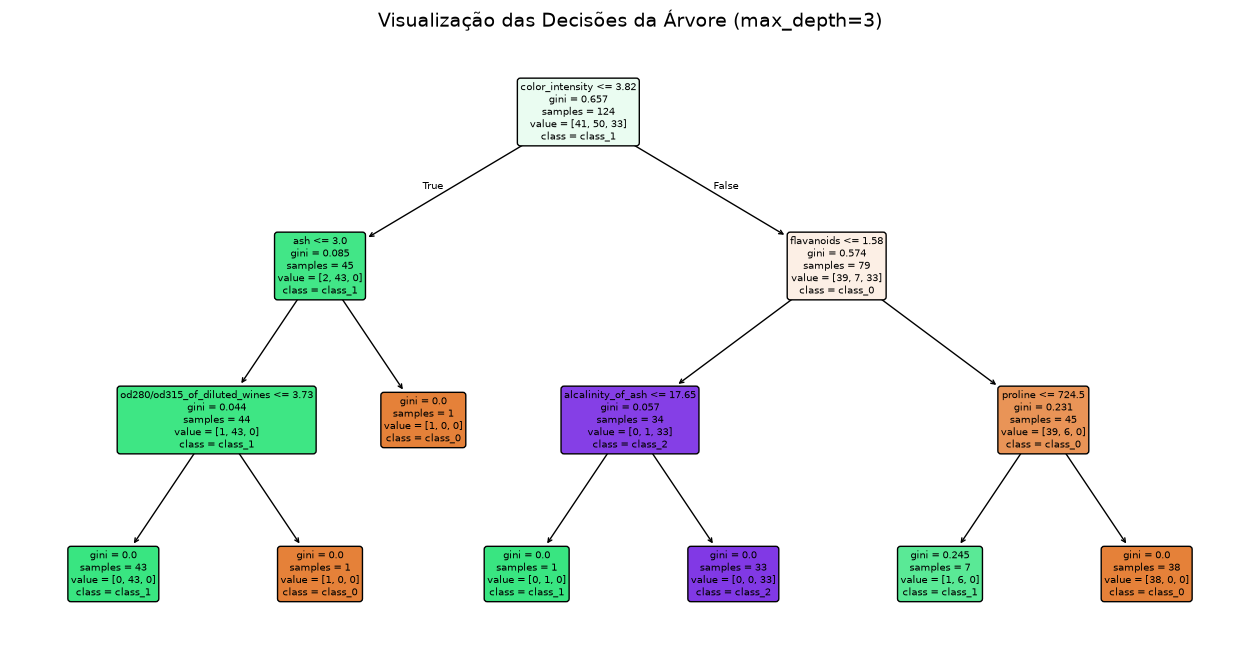

In [11]:
from sklearn.tree import DecisionTreeClassifier, plot_tree
import matplotlib.pyplot as plt

# 1. Treinamos a Árvore com profundidade controlada (max_depth=3)
arvore = DecisionTreeClassifier(max_depth=3, random_state=42)
arvore.fit(X_train, y_train) # Árvores não exigem scaling

# 2. Desenhamos a estrutura gráfica da árvore
plt.figure(figsize=(16, 8))
plot_tree(
    arvore, 
    feature_names=dados_vinho.feature_names, 
    class_names=dados_vinho.target_names, 
    filled=True, 
    rounded=True
)
plt.title("Visualização das Decisões da Árvore (max_depth=3)", fontsize=14)
plt.show()

---

### Passo 4 — Treinando Random Forest e SVM (Kernel RBF)

In [12]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score

# 1. Treinamos a Floresta Aleatória com 100 árvores
floresta = RandomForestClassifier(n_estimators=100, random_state=42)
floresta.fit(X_train, y_train)

# 2. Treinamos o Support Vector Machine
svm = SVC(kernel='rbf', C=1.0, random_state=42)
svm.fit(X_train_scaled, y_train)

# 3. Avaliamos a acurácia no teste
print(f"🌳 Acurácia Árvore Única:   {accuracy_score(y_test, arvore.predict(X_test)) * 100:.2f}%")
print(f"🌲 Acurácia Random Forest:  {accuracy_score(y_test, floresta.predict(X_test)) * 100:.2f}%")
print(f"🛡️ Acurácia SVM (RBF):      {accuracy_score(y_test, svm.predict(X_test_scaled)) * 100:.2f}%")

🌳 Acurácia Árvore Única:   96.30%
🌲 Acurácia Random Forest:  100.00%
🛡️ Acurácia SVM (RBF):      98.15%


---

### Passo 5 — Gráfico de Importância de Atributos (`feature_importances_`)

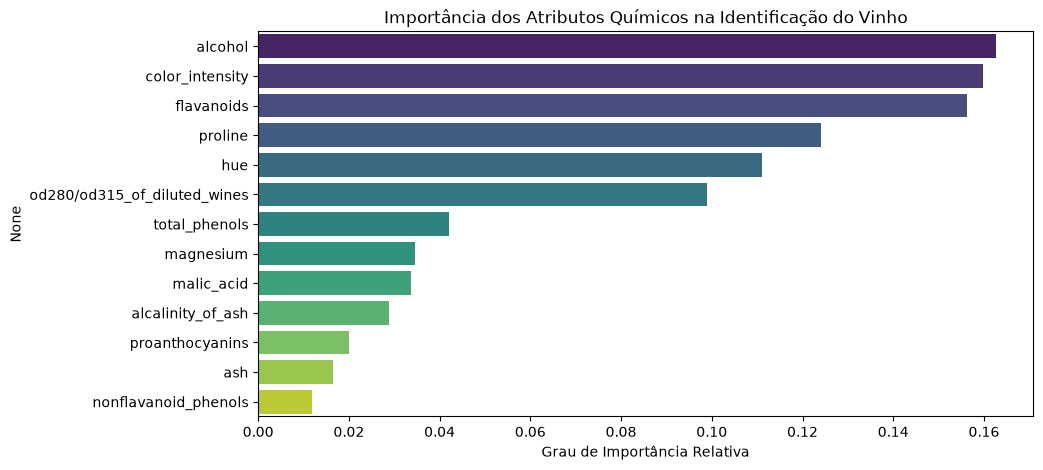

In [13]:
import seaborn as sns

# 1. Extraímos o peso de cada propriedade química usada pela Random Forest
importancias = pd.Series(floresta.feature_importances_, index=dados_vinho.feature_names).sort_values(ascending=False)

# 2. Plotamos o gráfico de barras
plt.figure(figsize=(10, 5))
sns.barplot(x=importancias.values, y=importancias.index, hue=importancias.index, palette='viridis', legend=False)
plt.title("Importância dos Atributos Químicos na Identificação do Vinho")
plt.xlabel("Grau de Importância Relativa")
plt.show()

---

## 🏆 Desafio Técnico de Validação
Identifique qual é o atributo químico mais decisivo do vinho segundo o gráfico de importância e teste treinar uma Random Forest utilizando apenas os 3 atributos do topo.

In [14]:
# =============================================================================
# RESOLUÇÃO DO DESAFIO TÉCNICO: TESTANDO TOP 3 ATRIBUTOS NA RANDOM FOREST
# =============================================================================

# 1. Identificamos os 3 atributos químicos mais decisivos pelo ranking de importância
top_3_features = list(importancias.index[:3])
print(f"🔬 Top 3 atributos mais decisivos identificados: {top_3_features}\n")

# 2. Filtramos os dados mantendo exclusivamente as 3 colunas selecionadas
X_train_top3 = X_train[top_3_features]
X_test_top3 = X_test[top_3_features]

# 3. Treinamos uma nova Random Forest apenas com as 3 variáveis
floresta_top3 = RandomForestClassifier(n_estimators=100, random_state=42)
floresta_top3.fit(X_train_top3, y_train)

# 4. Avaliamos a acurácia final nos dados de teste
acuracia_top3 = accuracy_score(y_test, floresta_top3.predict(X_test_top3))
acuracia_completa = accuracy_score(y_test, floresta.predict(X_test))

print("--- COMPARAÇÃO DE DESEMPENHO NO TESTE ---")
print(f"🌲 Random Forest (13 Atributos Completos): {acuracia_completa * 100:.2f}%")
print(f"🎯 Random Forest (Apenas Top 3 Atributos):  {acuracia_top3 * 100:.2f}%")

🔬 Top 3 atributos mais decisivos identificados: ['alcohol', 'color_intensity', 'flavanoids']



--- COMPARAÇÃO DE DESEMPENHO NO TESTE ---
🌲 Random Forest (13 Atributos Completos): 100.00%
🎯 Random Forest (Apenas Top 3 Atributos):  96.30%
